# HITO 3 – 
## Reconocimiento y Clasificación de Tumores Cerebrales – Desarrollo e Integración de Servicios de IA

### 1. Carga de los datos

In [3]:
from pathlib import Path
from tensorflow import keras
import os
import pandas as pd
random_state = 42
batch_size = 32  
image_size = (256,256)
directory = Path(".") / "data"/ "train"  # Directorio donde se ubican los datos
# Genera los datasets de train, validación y test a partir de las imágenes de los directorios
ds_train = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, seed = random_state)
directory = Path(".") / "data" / "val"
ds_validation = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, seed = random_state)
directory = Path(".") / "data" / "test"
ds_test = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, shuffle = False)

Found 1855 files belonging to 4 classes.
Found 617 files belonging to 4 classes.
Found 624 files belonging to 4 classes.


meningioma_tumor
glioma_tumor
pituitary_tumor
normal
Pesos para cada clase:
------------------------------------
{'meningioma_tumor': 0.19298399393371107, 'glioma_tumor': 0.19548563829951845, 'pituitary_tumor': 0.20862103692043474, 'normal': 0.40290933084633573}
------------------------------------
Frecuencia de aparición de cada clase:


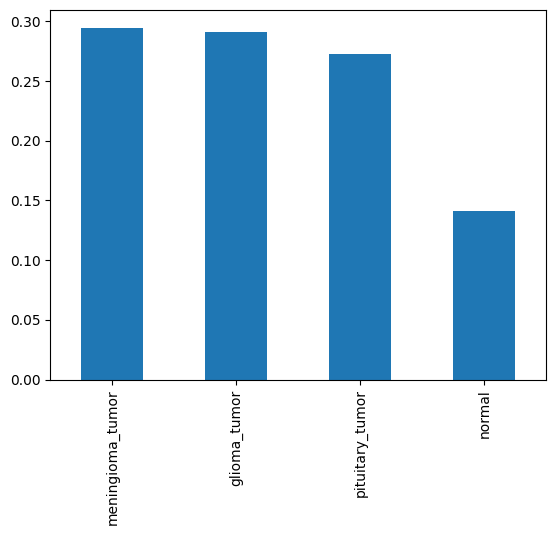

In [4]:
function = lambda file: file.split(os.sep)[2]
iterable = ds_train.file_paths
generator = map(function, iterable)

data = list(generator)  
normalize = True  
sort = True  
kind = "bar"  
frecuencias = pd.Series(data).value_counts(normalize, sort)
#print(frecuencias)
weights = {}
cont = 0
total = 0
for clase,frec in frecuencias.items():
    valor = 1/frec
    weights[clase]= valor
    total += valor
    cont+=1
#print(weights)
#normalizamos pesos
class_weights = {}
cont = 0
for clase,w in weights.items():
    print(clase)
    class_weights[clase] = w/total
    cont+=1
class_indices = {clase: idx for idx, clase in enumerate(frecuencias.keys())}
mapped_class_weights = {class_indices[clase]: peso for clase, peso in class_weights.items()}
print("Pesos para cada clase:")
print("------------------------------------")
print(class_weights)
print("------------------------------------")
print("Frecuencia de aparición de cada clase:")
pd.Series(data).value_counts(normalize, sort).plot(kind = kind);

### 2. Aumentación de datos

In [5]:
from keras import Sequential
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
data_augmentation = Sequential(
    [
        layers.RandomRotation(
        0.1, 
        fill_mode='constant', 
        fill_value=0.0       
        ),
        layers.RandomZoom(
            0.2, 
            fill_mode='constant', # esto hace que las zonas no ampliadas de la imagen se rellenen de color negro
            fill_value=0.0
        )
    ]
)

### 3. Modelos

In [6]:
import tensorflow as tf
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]

In [7]:
length = 79
model = Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation, #aplicamos la aumentación de datos
    layers.Rescaling(1./255),
    layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
    layers.Flatten(),
    layers.Dropout(0.5), #aplicamos dropout
    layers.Dense(4, activation="softmax")
])
model.summary(length)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                     ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)          │ (None, 256, 256, 3)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling (Rescaling)            │ (None, 256, 256, 3)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                  │ (None, 254, 254, 32)     │           896 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)     │ (None, 127, 127, 32)     │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                │ (None, 125, 125, 64)     │        18,496 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)   │ (None, 62, 62, 64)       │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                │ (None, 60, 60, 128)      │        73,856 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)   │ (None, 30, 30, 128)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                │ (None, 28, 28, 256)      │       295,168 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)   │ (None, 14, 14, 256)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)                │ (None, 12, 12, 256)      │       590,080 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten (Flatten)                │ (None, 36864)            │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                │ (None, 36864)            │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                    │ (None, 4)                │       147,460 │
└──────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,125,956 (4.30 MB)

 Trainable params: 1,125,956 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
lr = 0.001
optimizer = tf.keras.optimizers.Adam(lr)

model.compile(optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [9]:
history = model.fit(
    x = ds_train,
    epochs=100,
    validation_data= ds_validation,
    callbacks=callbacks,
    class_weight=mapped_class_weights)
model.save("convnet.keras")

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 593ms/step - accuracy: 0.2701 - loss: 0.3301 - val_accuracy: 0.2723 - val_loss: 1.3457
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 542ms/step - accuracy: 0.4016 - loss: 0.2824 - val_accuracy: 0.4360 - val_loss: 1.3333
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 545ms/step - accuracy: 0.5423 - loss: 0.2384 - val_accuracy: 0.5592 - val_loss: 0.9506
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 560ms/step - accuracy: 0.6065 - loss: 0.2042 - val_accuracy: 0.6094 - val_loss: 0.9391
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 530ms/step - accuracy: 0.6318 - loss: 0.1990 - val_accuracy: 0.5835 - val_loss: 1.1032
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 29s 501ms/step - accuracy: 0.6555 - loss: 0.1798 - val_accuracy: 0.6207 - val_loss: 1.0050
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 28s 489ms/step - accuracy: 0.6550 - loss: 0.1907 - val_accuracy: 0.5413 - val_loss: 1.1828
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 29s 497ms/step - accuracy: 0.6863 - loss: 0.1637 - 